In [1]:
%matplotlib widget
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy
import h5py

import os
import sys
print(os.getpid())
sys.path.append(os.path.abspath("./"))
%cd ../../

import pylib.mix as mix
import cvxpy as cp
import pylib.qucf_read as qucf_r
import pylib.measurement as mse

import pylib.Chebyschev_coefs as ch

import stepanoff

from matplotlib import colors
colors_ = ["blue", "red", "green", "gray", "black"]

plt.rcParams.update({
    "text.usetex": True,
    'text.latex.preamble': r"\usepackage{amsmath} \boldmath"
})

21900
c:\Users\ivan9\Documents\work\codes\QuCF\scripts-py


In [2]:
path_save_      = "./jupyter-notebooks/Stepanoff/results/"
path_qucf_root_ = "../QuCF/simulations/Stepanoff/"
for i in range(100):
    plt.close()

In [3]:
# -------------------------------------------------------------------
# --- Main parameters ---
# -------------------------------------------------------------------
mix.reload_module(mix)
mix.reload_module(stepanoff)
def compute_sin_pars():
    alpha_0_sin = x_[1 << nx_half_]
    alpha_1_sin = (2. * np.pi - alpha_0_sin) * Nx_half_/(2.*(Nx_half_ - 1))
    print()
    print("// --- For sin function ---")
    print("\tNx_half_m_one \t{:d}".format(Nx_half_ - 1))
    print("\talpha_sin_0 \t{:0.12e}".format(alpha_0_sin))
    print("\talpha_sin_1 \t{:0.12e}".format(alpha_1_sin))
    return
# -----------------------------------------------------
# --- Parameters for temporal and spatial grids ---
# Total time interval is dt_ * Nt_
# -----------------------------------------------------------------
# Here, rr_init_ takes into account AA of the initialization     
# rr_init_ is computed in ./init_mod_QSVT.ipynb by comparing of  
# the QuCF simulation of the non-amplified initial condition and 
# the QuCF simulation of the amplified initial condition     
# -----------------------------------------------------------------    

# --- These parameters were used for amplitude estimation ---
dt_, Nt_ = 0.1, 10
nx_, rr_init_ = 6, 3.216984647198e+00

# --- other parameters ---
alpha_ = np.sqrt(20.)
kappa_ = 1.

# --- spatial grid ---
Nx_ = 1 << nx_
nx_half_ = nx_ - 1
Nx_half_ = 1 << nx_half_
x_ = np.linspace(0., 2.*np.pi, Nx_)

compute_sin_pars()

# --- unitary operators ---
init_2d_    = stepanoff.f_init_2d(kappa_, x_, Nx_)
diag_U_M1_  = stepanoff.create_diag_matrix(dt_, Nx_half_, alpha_, "M1", True)
diag_U_M2_  = stepanoff.create_diag_matrix(dt_, Nx_half_, alpha_, "M2", True)


// --- For sin function ---
	Nx_half_m_one 	31
	alpha_sin_0 	3.191459203647e+00
	alpha_sin_1 	1.595729601823e+00


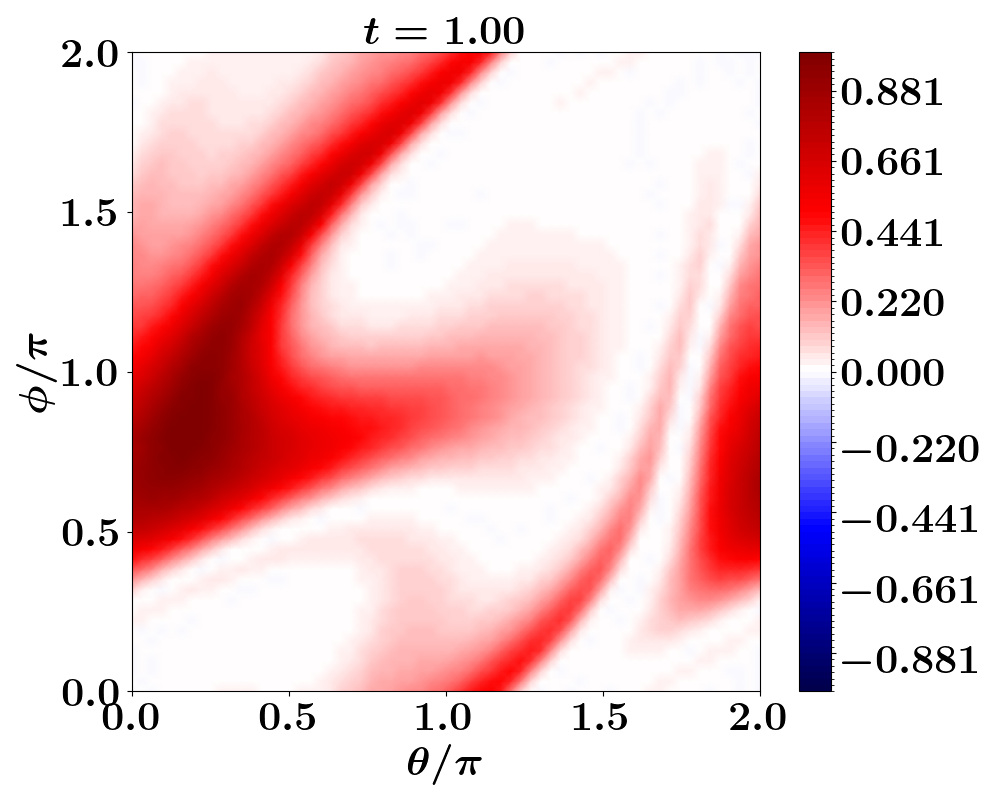

In [4]:
# -------------------------------------------------------------------
# --- Classical simulations in real-Fourier space  ---
# -------------------------------------------------------------------
mix.reload_module(mix)
mix.reload_module(stepanoff)
y_cl_mod_mix_, y_cl_mix_ = stepanoff.computation_in_real_and_fourier(
    dt_, Nt_, x_,
    diag_U_M1_, diag_U_M2_, init_2d_,
    flag_plot = True,
    flag_norm_max = False
)

In [5]:
# -------------------------------------------------------------------
# --- Functions for computing observables directly ---
# -------------------------------------------------------------------
def compute_observable_direct_(psi_mod):
    Nx = np.shape(psi_mod)[0]
    res_v = 0.
    for i_phi in range(Nx):
        for i_theta in range(Nx):
            if i_theta >= Nx_half_ and i_phi >= Nx_half_:
                res_v += np.abs(psi_mod[i_theta, i_phi])**2
    res_v /= Nx_**2
    return res_v
# --------------------------------------------------------------------
def compute_observable_cos_phi_(psi_mod):
    Nx = np.shape(psi_mod)[0]
    res_v = 0.
    for i_phi in range(Nx):
        for i_theta in range(Nx):
            res_v += np.abs(psi_mod[i_phi, i_theta])**2 * np.cos(x_[i_phi])**2
    res_v /= Nx**2
    return res_v
# --------------------------------------------------------------------
def compute_observable_cos_sin_phi_(psi_mod):
    Nx = np.shape(psi_mod)[0]
    res_v = 0.
    for i_phi in range(Nx):
        for i_theta in range(Nx):
            if i_theta >= Nx_half_:
                res_v += np.abs(psi_mod[i_phi, i_theta])**2 * np.cos(x_[i_phi])**2 * np.sin(x_[i_theta])**2
            else:
                res_v += np.abs(psi_mod[i_phi, i_theta])**2 * np.cos(x_[i_phi])**2
    res_v /= Nx**2
    return res_v

Reading the file ../QuCF/simulations/Stepanoff//sim_diag_dt0.100_AE_cos_sin/sim_nx6_t1_ny6_OUTPUT.hdf5...
Reading probabilities for the initial conditions 0.
Name of the simulation is sim
Simulation has been performed  07-26-2025 10:52:03

A-max: 5.766321695614e-06
success prob: 4.472e-09
N-gates: 33841994

---------------------------------------------------------------
Reading the file ../QuCF/simulations/Stepanoff//sim_diag_dt0.100/sim_nx6_t1_OUTPUT.hdf5...
Probabilities have been saved in these QuCF simulations.
Name of the simulation is sim
Simulation has been performed  04-03-2025 14:22:00

A-max: 1.001615032781e+00
success prob: 4.120e+02
N-gates: 266454

QC:       Q: 3.105e-02
QC-wo-AE: Q: 3.108e-02
CL:       Q: 3.108e-02

err: 4.804e-03
Q + err: 3.585e-02
Q - err: 2.624e-02


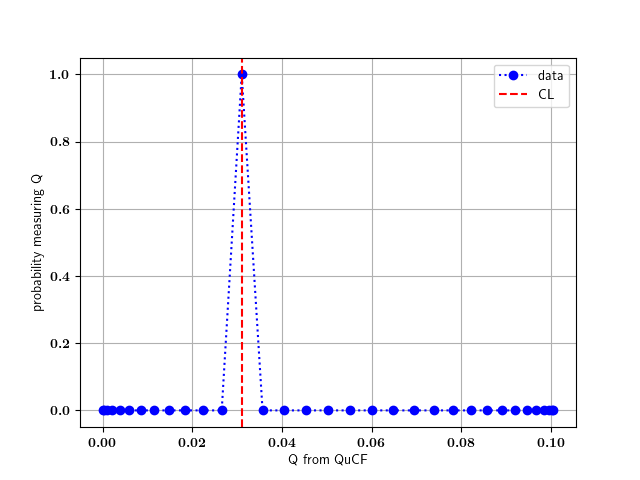

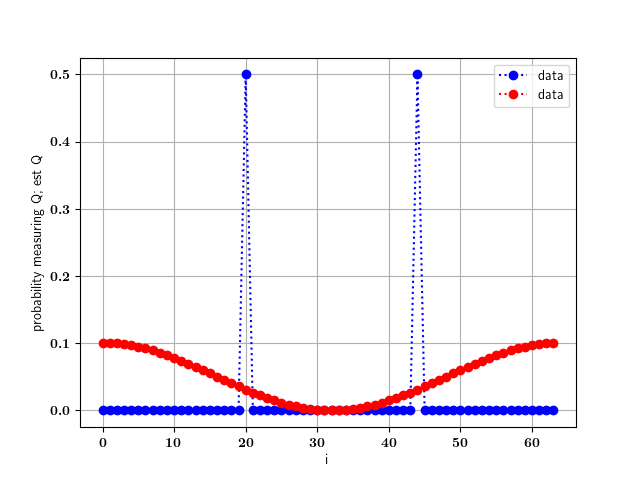

write data to a file: ./jupyter-notebooks/Stepanoff/results//scaling_AE_cos_sin_ny6.dat


In [ ]:
# -------------------------------------------------------------------
# --- Compare classical and QuCF results ---
# -------------------------------------------------------------------
mix.reload_module(mix)
mix.reload_module(stepanoff)
def compare_classical_qucf(y_cl_mod_mix, path_qc, name_file_qc, flag_save):
    def reading_qucf(path_qc_loc, name_file_qc_loc):
        # --- Read the _OUTPUT.hdf5 file ---
        om = mse.MeasOracle__()
        om.path_  = path_qc_loc
        om.pname_ = name_file_qc_loc
        om.open()
        
        # --- get the result ---
        Ngates = om.dd_["N-gates"]
        om.set_zero_ancillae_work_states(0)
        qc_state = om.get_var_x({}, "r")

        om.read_qsvt()
        resc_qsvt = om.dd_["init"]["rescaling_factor"]
        Hadamart_norm_factor = 2.**(nx_//2)
        resc_coef = Hadamart_norm_factor**2 / (resc_qsvt**2 * rr_init_)
        qc_state *= resc_coef
        
        print()
        print("A-max: {:0.12e}".format(np.max(np.abs(qc_state))))
        print("success prob: {:0.3e}".format(  np.sum(np.abs(qc_state)**2)  ))
        print("N-gates: {:d}".format(Ngates))

        return qc_state, resc_coef, om
    # ------------------------------------------------------
    _, resc_coef, om = reading_qucf(path_qc, name_file_qc)

    # --- reading AE ---
    probs_meas = om.probs_  # probabilities to measure different integer outcomes in the register y
    del om

    N_y_points = len(probs_meas)
    int_ys = np.array(range(N_y_points)) # integer outcomes in the register y

    eig_phases = np.pi * int_ys / N_y_points # measured estimations of the eigenphases of the AA operator
    probs_est = 1. - np.sin(eig_phases)**2   # measured probabilities of the "good" (useful) state
    id_max_qc   = np.where(probs_meas == np.max(probs_meas))[0][0]
    probs_est_max = probs_est[id_max_qc] # the most probable probability amplitude of the good state

    coef_from_prob_to_Q = (resc_coef / Nx_)**2

    Q_est_array = probs_est * coef_from_prob_to_Q # all possible estimated values of Q
    Q_est       = Q_est_array[id_max_qc]          # the most probable estimation of Q

    analytical_abs_error = 2*np.pi*np.sqrt(probs_est_max*(1-probs_est_max))/N_y_points + np.pi**2/(N_y_points**2)
    analytical_abs_error *= coef_from_prob_to_Q

    # --- Construct probability and Q-est arrays ---
    # Here, we take into account that the estimation of Q is repeated twice
    Ny_half_one = N_y_points//2 + 1
    prob_array_plot  = np.zeros(Ny_half_one)
    Q_est_array_plot = np.zeros(Ny_half_one)
    for ii in range(N_y_points):
        if ii < Ny_half_one:
            prob_array_plot[ii]  = probs_meas[ii]
            Q_est_array_plot[ii] = Q_est_array[ii] 
        else:
            prob_ref = prob_array_plot[N_y_points - ii]
            prob_1   = probs_meas[ii]
            prob_array_plot[N_y_points - ii] = prob_ref + prob_1

    # --- CL value ---
    Q_cl = compute_Q(y_cl_mod_mix)

    # --- Reading data from QuCF simulations without AE ---
    print("\n---------------------------------------------------------------")
    qc_state_woAE, _, _ = reading_qucf(path_qucf_woAE, file_output_woAE)
    psi_qc_2d = stepanoff.rearrange_into_2d(qc_state_woAE, Nx_)
    Q_qucf_woAE = compute_Q(np.transpose(psi_qc_2d))

    # --- Printing results ----
    print()
    print("QC:       Q: {:0.3e}".format(Q_est))
    print("QC-wo-AE: Q: {:0.3e}".format(Q_qucf_woAE))
    print("CL:       Q: {:0.3e}".format(Q_cl))
    print()
    print("err: {:0.3e}".format(analytical_abs_error))
    print("Q + err: {:0.3e}".format(Q_est + analytical_abs_error))
    print("Q - err: {:0.3e}".format(Q_est - analytical_abs_error))

    # ----------------------------------------------------------
    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.plot(
        Q_est_array_plot, prob_array_plot, 
        color='b', marker="o", linestyle = ':', label = "data"
    )
    ax.axvline(
        x=Q_cl, 
        color='red', 
        linestyle = '--', 
        label = "CL"
    )
    plt.xlabel("Q from QuCF")
    plt.ylabel("probability measuring Q")
    ax.legend()
    plt.grid(True)
    # plt.xlim(0., 200.)
    plt.show()

    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.plot(
        int_ys, probs_meas, 
        color='b', marker="o", linestyle = ':', label = "data"
    )
    ax.plot(
        int_ys, Q_est_array, 
        color='r', marker="o", linestyle = ':', label = "data"
    )
    plt.xlabel("i")
    plt.ylabel("probability measuring Q; est Q")
    ax.legend()
    plt.grid(True)
    plt.show()

    # ----------------------------------------------------------
    if flag_save:
        mix.save_dat_plot_1d_file(
            path_save_ + "/scaling_AE_{:s}_ny{:d}.dat".format(case_Q, ny), 
            Q_est_array_plot, prob_array_plot
        )
    return 
# ----------------------------------------------------------------------
flag_save = False

case_Q, ny = "cos", 4
# case_Q, ny = "cos_sin", 6
# case_Q, ny = "direct", 6

path_qucf_ = path_qucf_root_ + "/sim_diag_dt{:0.3f}_AE_{:s}".format(dt_, case_Q)
file_output = "sim_nx{:d}_t{:d}_ny{:d}".format(nx_, int(Nt_*dt_), ny)

path_qucf_woAE = path_qucf_root_ + "/sim_diag_dt{:0.3f}".format(dt_)
file_output_woAE = "sim_nx{:d}_t{:d}".format(nx_, int(Nt_*dt_))

if case_Q == "cos":
    compute_Q = compute_observable_cos_phi_
if case_Q == "cos_sin":
    compute_Q = compute_observable_cos_sin_phi_
if case_Q == "direct":
    compute_Q = compute_observable_direct_
    path_qucf_ = path_qucf_root_ + "/sim_diag_dt{:0.3f}_AE_simple".format(dt_)
    file_output = "sim_ny{:d}".format(ny)


compare_classical_qucf(y_cl_mod_mix_, path_qucf_, file_output, flag_save)
del flag_save, case_Q, ny, file_output, compute_Q, path_qucf_woAE, file_output_woAE